<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans.


## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab


In [1]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

ModuleNotFoundError: No module named 'piplite'

In [2]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [ ]:

import requests
import io

# The dataset URL
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"

# Standard Python replacement for the browser-only 'js' fetch
try:
    # Most standard environments can read the URL directly through pandas
    df = pd.read_csv(URL)
    print("Dataset loaded successfully using pandas.read_csv()!")
except Exception as e:
    # Robust fallback using the requests library if direct reading is blocked
    print(f"Direct read encountered an issue: {e}")
    print("Attempting fallback download using the requests library...")
    response = requests.get(URL)
    df = pd.read_csv(io.BytesIO(response.content))
    print("Dataset loaded successfully using requests fallback!")

# Display the first 5 rows of the dataframe to confirm successful loading
print("\nFirst 5 rows of the dataset:")
print(df.head())

Dataset loaded successfully using pandas.read_csv()!

First 5 rows of the dataset:
   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Ocean        1     False   False  False        NaN    1.0   
4    None None        1     False   False  False        NaN    1.0   

   ReusedCount Serial

First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.


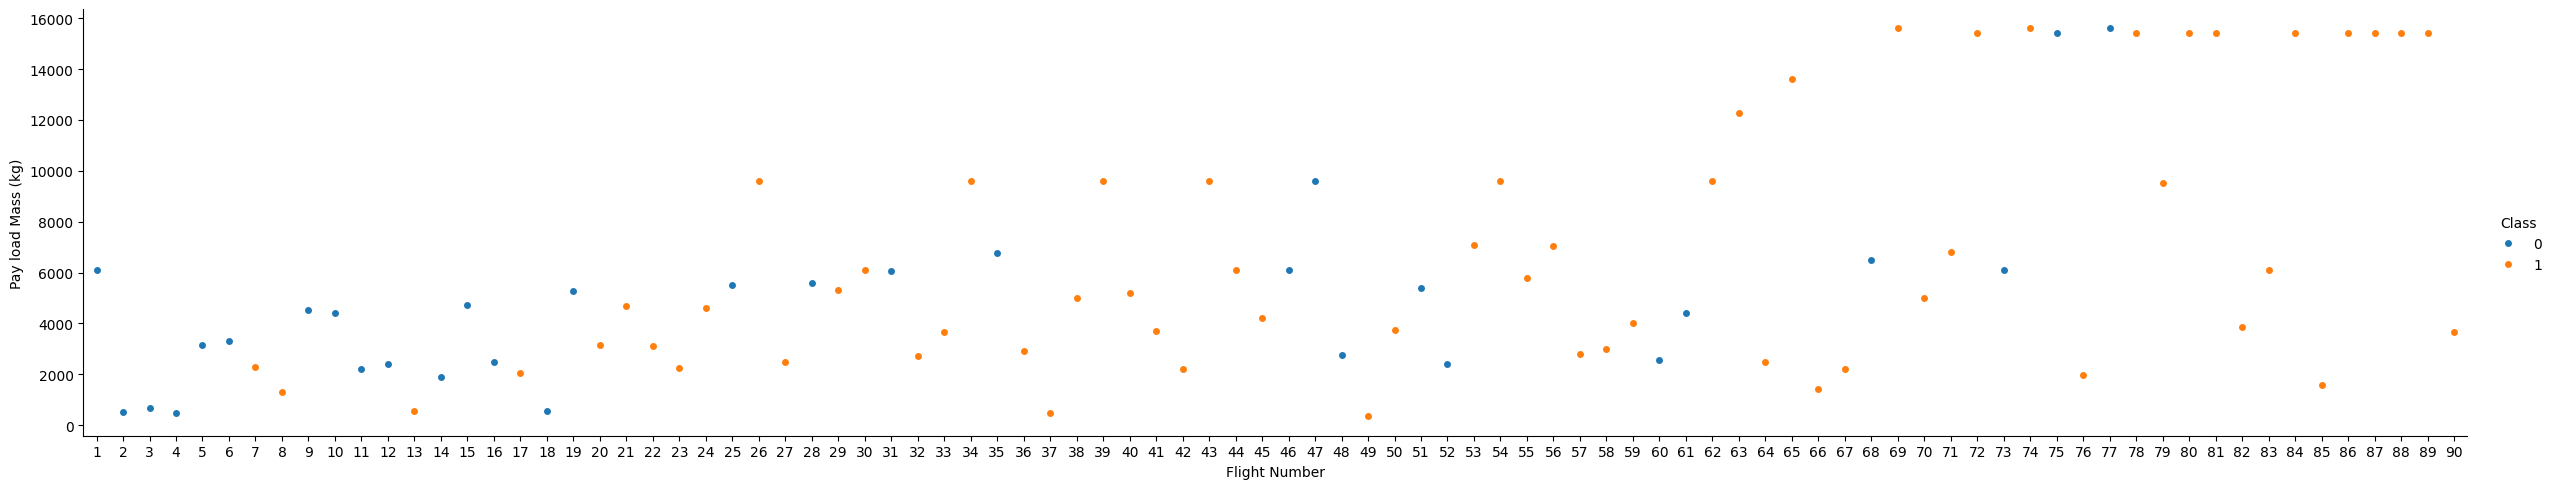

In [7]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number")
plt.ylabel("Pay load Mass (kg)")
plt.show()

We see that different launch sites have different success rates.  <code>CCAFS LC-40</code>, has a success rate of 60 %, while  <code>KSC LC-39A</code> and <code>VAFB SLC 4E</code> has a success rate of 77%.


Next, let's drill down to each site visualize its detailed launch records.


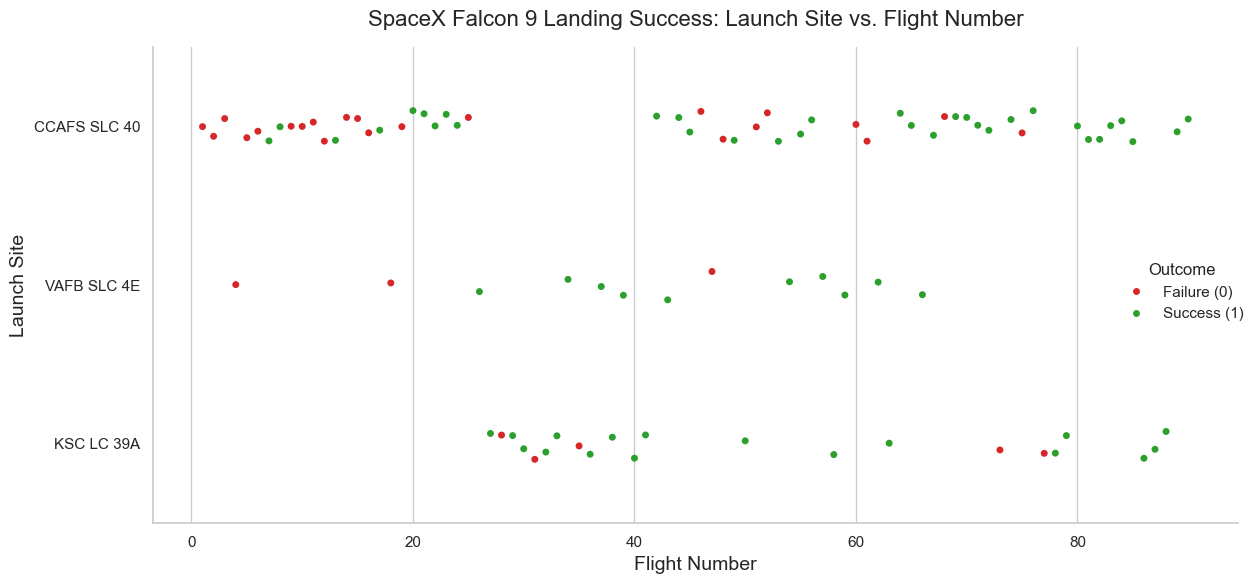

In [8]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value

# Set the style and font size for clean styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

# Create the categorical scatter plot (stripplot) using catplot
# We map FlightNumber to x, LaunchSite to y, and Class to the color hue
g = sns.catplot(
    data=df, 
    x="FlightNumber", 
    y="LaunchSite", 
    hue="Class", 
    aspect=2,      # Adjust aspect ratio to make it wide and readable
    height=6,      # Height of the plot in inches
    palette={1: "#2ca02c", 0: "#d62728"} # Green for success, Red for failure
)

# Set descriptive labels and title
g.set_xlabels("Flight Number", fontsize=14)
g.set_ylabels("Launch Site", fontsize=14)
plt.title("SpaceX Falcon 9 Landing Success: Launch Site vs. Flight Number", fontsize=16, pad=15)

# Adjust the legend position and clean up labels
g._legend.set_title("Outcome")
for t, l in zip(g._legend.texts, ["Failure (0)", "Success (1)"]):
    t.set_text(l)

# Show the plot
plt.tight_layout()
plt.show()

Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


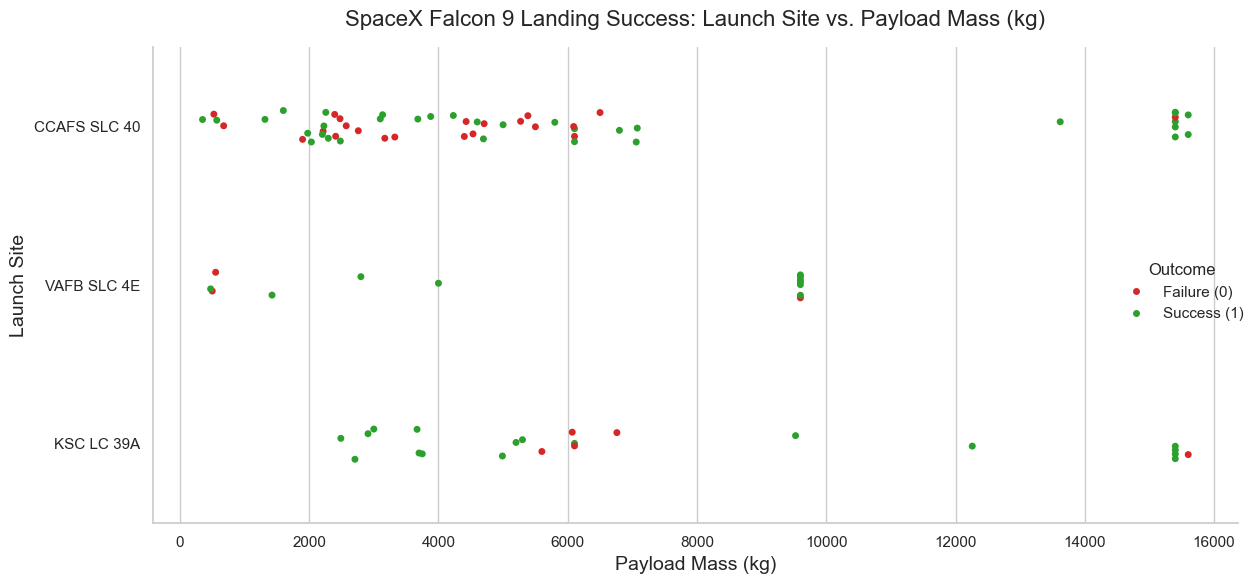

In [10]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value

# Set the style and font size for clean styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

# Create the categorical scatter plot (stripplot) using catplot
# We map PayloadMass to x, LaunchSite to y, and Class to the color hue
g = sns.catplot(
    data=df, 
    x="PayloadMass", 
    y="LaunchSite", 
    hue="Class", 
    aspect=2,      # Widen the canvas to prevent overlapping points
    height=6,      # Height of the plot in inches
    palette={1: "#2ca02c", 0: "#d62728"} # Green for success (1), Red for failure (0)
)

# Set descriptive labels and title
g.set_xlabels("Payload Mass (kg)", fontsize=14)
g.set_ylabels("Launch Site", fontsize=14)
plt.title("SpaceX Falcon 9 Landing Success: Launch Site vs. Payload Mass (kg)", fontsize=16, pad=15)

# Adjust the legend title and clean up the labels
g._legend.set_title("Outcome")
for t, l in zip(g._legend.texts, ["Failure (0)", "Success (1)"]):
    t.set_text(l)

# Display the plot
plt.tight_layout()
plt.show()

Let's create a `bar chart` for the sucess rate of each orbit


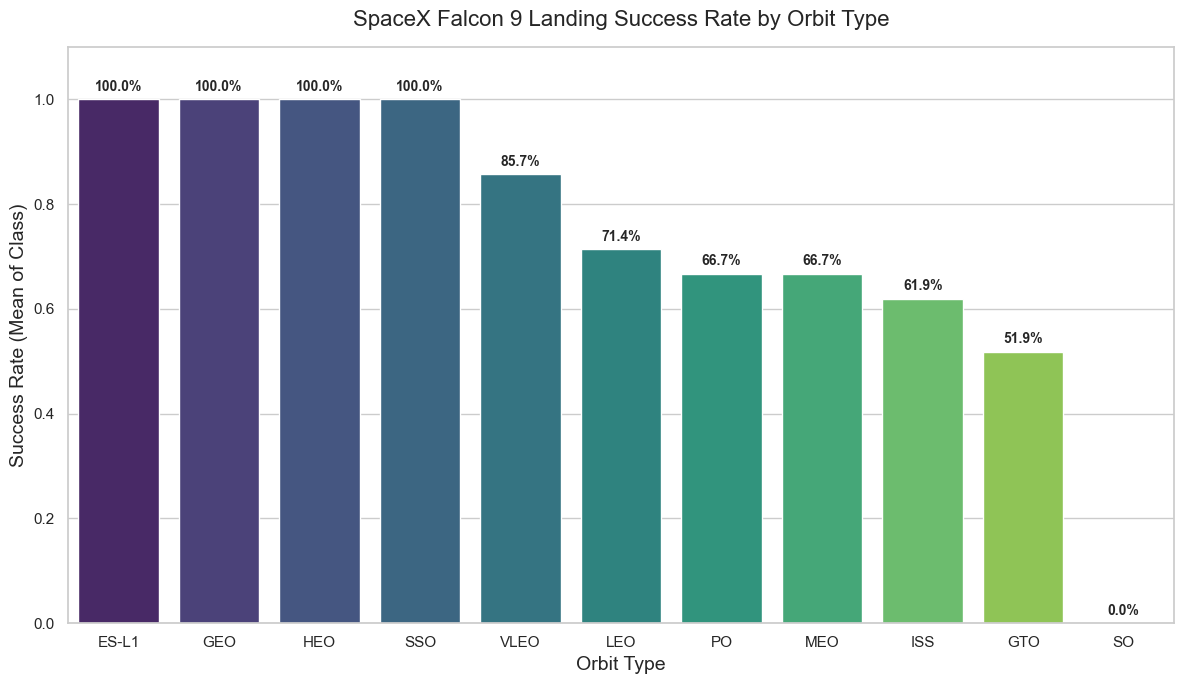

In [12]:
# HINT use groupby method on Orbit column and get the mean of Class column

sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

#  Calculate the average success rate for each orbit type
# We group by 'Orbit' and compute the mean of the binary 'Class' column (1 for Success, 0 for Failure)
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()

#  Sort the dataframe by success rate descending for better visual storytelling
orbit_success = orbit_success.sort_values(by="Class", ascending=False)

#  Create the bar plot
plt.figure(figsize=(12, 7))
g = sns.barplot(
    data=orbit_success, 
    x="Orbit", 
    y="Class", 
    hue="Orbit", # Map hue to orbit to allow color customization
    palette="viridis", # Clean gradient palette
    legend=False # Hide redundant legend
)

# Add value labels on top of each bar for precise reading
for p in g.patches:
    g.annotate(
        format(p.get_height() * 100, '.1f') + '%', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        xytext=(0, 9), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

# Set descriptive labels and title
plt.xlabel("Orbit Type", fontsize=14)
plt.ylabel("Success Rate (Mean of Class)", fontsize=14)
plt.title("SpaceX Falcon 9 Landing Success Rate by Orbit Type", fontsize=16, pad=15)
plt.ylim(0, 1.1) # Extend y-axis slightly above 100% to accommodate labels safely

# Display the plot
plt.tight_layout()
plt.show()

Analyze the ploted bar chart try to find which orbits have high sucess rate.


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


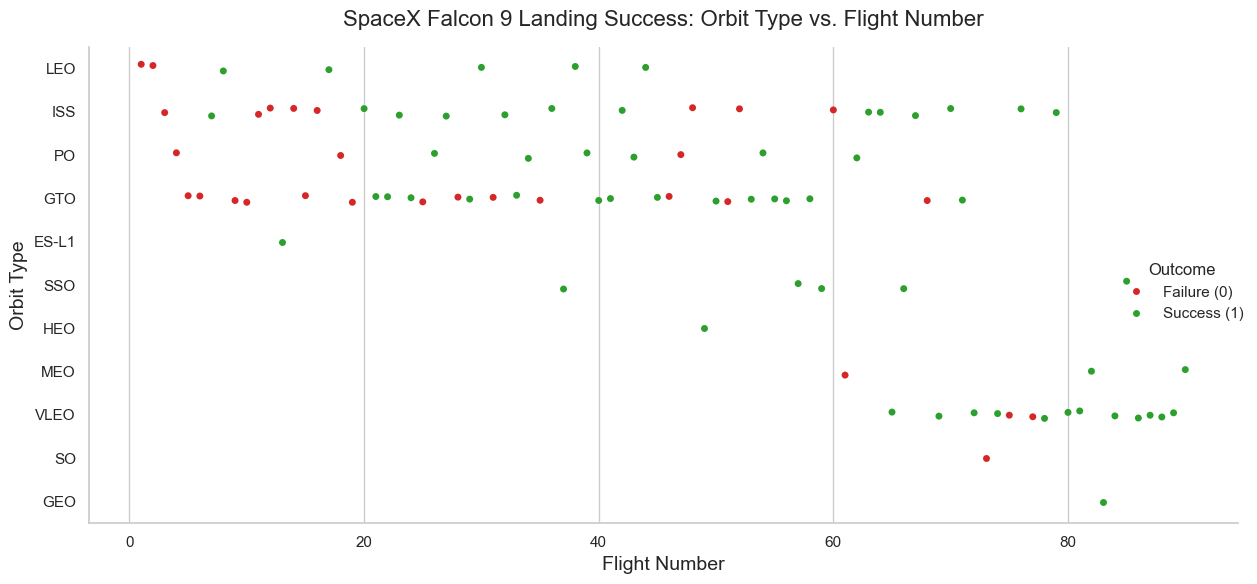

In [14]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value
# Set the style and font size for clean styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 12

# Create the categorical scatter plot (stripplot) using catplot
# We map FlightNumber to x, Orbit to y, and Class to the color hue
g = sns.catplot(
    data=df, 
    x="FlightNumber", 
    y="Orbit", 
    hue="Class", 
    aspect=2,      # Widen the canvas to prevent overlapping points
    height=6,      # Height of the plot in inches
    palette={1: "#2ca02c", 0: "#d62728"} # Green for success (1), Red for failure (0)
)

# Set descriptive labels and title
g.set_xlabels("Flight Number", fontsize=14)
g.set_ylabels("Orbit Type", fontsize=14)
plt.title("SpaceX Falcon 9 Landing Success: Orbit Type vs. Flight Number", fontsize=16, pad=15)

# Adjust the legend title and clean up the labels
g._legend.set_title("Outcome")
for t, l in zip(g._legend.texts, ["Failure (0)", "Success (1)"]):
    t.set_text(l)

# Display the plot
plt.tight_layout()
plt.show()

You should see that in the LEO orbit the Success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number when in GTO orbit.


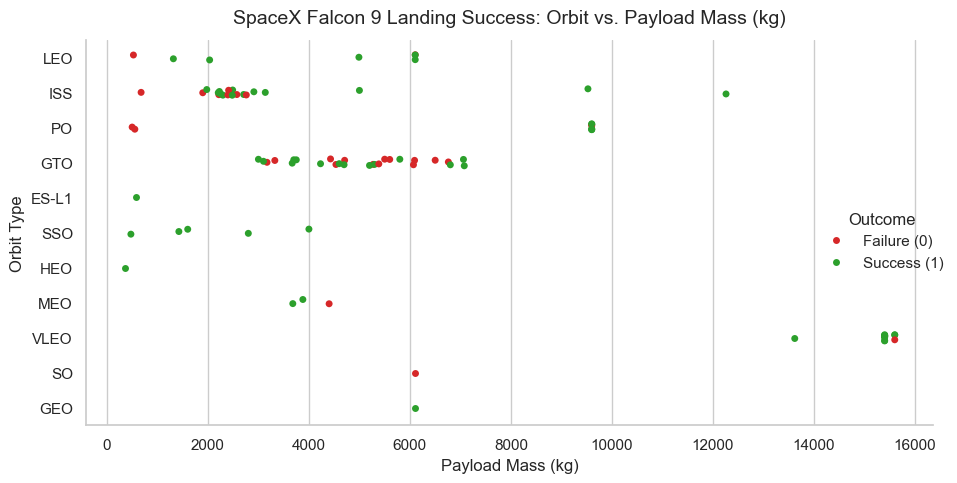

In [15]:

# Set theme style
sns.set_theme(style="whitegrid")

# Create a compact scatter plot of Payload Mass vs Orbit
g = sns.catplot(
    data=df, 
    x="PayloadMass", 
    y="Orbit", 
    hue="Class", 
    aspect=1.8, 
    height=5,
    palette={1: "#2ca02c", 0: "#d62728"}
)

# Set labels and title
g.set_xlabels("Payload Mass (kg)", fontsize=12)
g.set_ylabels("Orbit Type", fontsize=12)
plt.title("SpaceX Falcon 9 Landing Success: Orbit vs. Payload Mass (kg)", fontsize=14, pad=12)

# Format the legend
g._legend.set_title("Outcome")
for t, l in zip(g._legend.texts, ["Failure (0)", "Success (1)"]):
    t.set_text(l)

plt.tight_layout()
plt.show()

Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.

However for GTO we cannot distinguish this well as both positive landing rate and negative landing(unsuccessful mission) are both there here.


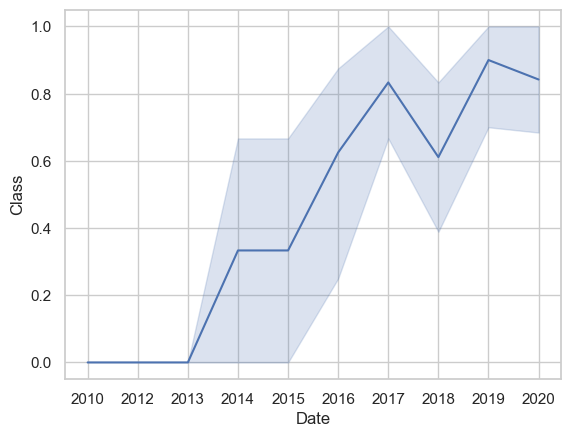

In [17]:
### TASK  6: Visualize the launch success yearly trend
sns.lineplot(y="Class", x="Date", data=df)
plt.xlabel("Date")
plt.ylabel("Class")
plt.show()

You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.


The function will help you get the year from the date:


In [18]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()
    

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


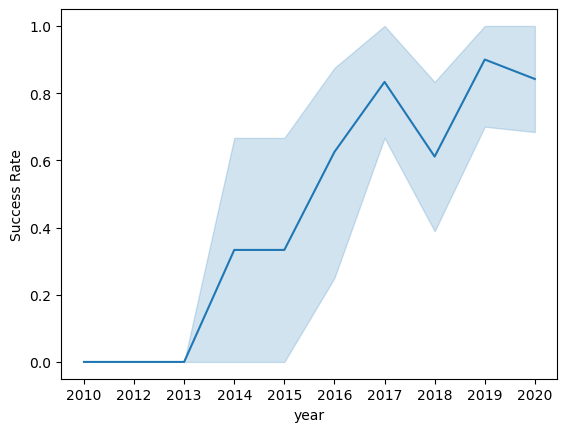

In [30]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
sns.lineplot(data=df, x="Date", y="Class") 
plt.xlabel("year")
plt.ylabel("Success Rate")
plt.show()

you can observe that the sucess rate since 2013 kept increasing till 2020


## Features Engineering


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [19]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [ ]:
# HINT: Use get_dummies() function on the categorical columns

# Extract the standard features dataframe used for machine learning modeling
# This includes numeric, boolean, and categorical columns
features = df[[
    'FlightNumber', 
    'PayloadMass', 
    'Orbit', 
    'LaunchSite', 
    'Flights', 
    'GridFins', 
    'Reused', 
    'Legs', 
    'LandingPad', 
    'Block', 
    'ReusedCount', 
    'Serial'
]]

#  Apply One-Hot Encoding using pd.get_dummies()
# We target the categorical columns: 'Orbit' (referred to as Orbits), 'LaunchSite', 'LandingPad', and 'Serial'
categorical_cols = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']
features_one_hot = pd.get_dummies(features, columns=categorical_cols)

#  Cast all dummy/one-hot columns to float64 (optional but highly recommended for subsequent ML steps)
# This converts the binary True/False or 1/0 values to standard float representations
features_one_hot = features_one_hot.astype('float64')

#  Display the results
print("=== Original Features Shape ===")
print(features.shape)

print("\n=== One-Hot Encoded Features Shape ===")
print(features_one_hot.shape)

print("\n=== Head of the Encoded Dataframe (First 5 Rows) ===")
# Display the first 5 rows containing both the original numeric columns and the new dummy variables
print(features_one_hot.head())

=== Original Features Shape ===
(90, 12)

=== One-Hot Encoded Features Shape ===
(90, 80)

=== Head of the Encoded Dataframe (First 5 Rows) ===
   FlightNumber  PayloadMass  Flights  GridFins  Reused  Legs  Block  \
0           1.0  6104.959412      1.0       0.0     0.0   0.0    1.0   
1           2.0   525.000000      1.0       0.0     0.0   0.0    1.0   
2           3.0   677.000000      1.0       0.0     0.0   0.0    1.0   
3           4.0   500.000000      1.0       0.0     0.0   0.0    1.0   
4           5.0  3170.000000      1.0       0.0     0.0   0.0    1.0   

   ReusedCount  Orbit_ES-L1  Orbit_GEO  ...  Serial_B1048  Serial_B1049  \
0          0.0          0.0        0.0  ...           0.0           0.0   
1          0.0          0.0        0.0  ...           0.0           0.0   
2          0.0          0.0        0.0  ...           0.0           0.0   
3          0.0          0.0        0.0  ...           0.0           0.0   
4          0.0          0.0        0.0  ...     

In [21]:
### TASK  8: Cast all numeric columns to `float64`
features_one_hot.astype(float)

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
86,87.0,15400.000000,3.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
87,88.0,15400.000000,6.0,1.0,1.0,1.0,5.0,5.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
88,89.0,15400.000000,3.0,1.0,1.0,1.0,5.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


In [23]:
# HINT: use astype function
#TASK 8: Cast all numeric columns to float64
# Now that our features_one_hot dataframe only contains numbers, we cast the entire dataframe to float64
features_one_hot = features_one_hot.astype('float64')

# Display the final verification results
print("=== Original Features Shape ===")
print(features.shape)

print("\n=== One- Hot Encoded Features Shape ===")
print(features_one_hot.shape)

print("\n=== Head of the Encoded Dataframe (First 5 Rows) ===")
# Display the first 5 rows containing both the original numeric columns and the new dummy variables
print(features_one_hot.head())

print("\n=== Data Types of the First 10 Columns ===")
# Explicitly verify that the columns have been cast to float64
print(features_one_hot.dtypes.head(10))

=== Original Features Shape ===
(90, 12)

=== One- Hot Encoded Features Shape ===
(90, 80)

=== Head of the Encoded Dataframe (First 5 Rows) ===
   FlightNumber  PayloadMass  Flights  GridFins  Reused  Legs  Block  \
0           1.0  6104.959412      1.0       0.0     0.0   0.0    1.0   
1           2.0   525.000000      1.0       0.0     0.0   0.0    1.0   
2           3.0   677.000000      1.0       0.0     0.0   0.0    1.0   
3           4.0   500.000000      1.0       0.0     0.0   0.0    1.0   
4           5.0  3170.000000      1.0       0.0     0.0   0.0    1.0   

   ReusedCount  Orbit_ES-L1  Orbit_GEO  ...  Serial_B1048  Serial_B1049  \
0          0.0          0.0        0.0  ...           0.0           0.0   
1          0.0          0.0        0.0  ...           0.0           0.0   
2          0.0          0.0        0.0  ...           0.0           0.0   
3          0.0          0.0        0.0  ...           0.0           0.0   
4          0.0          0.0        0.0  ...    

We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


<code>features_one_hot.to_csv('dataset_part\_3.csv', index=False)</code>


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork865-2022-01-01)


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
